In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


## 1. Simple harmonic motion
x¨+ω0^(2)​x=0

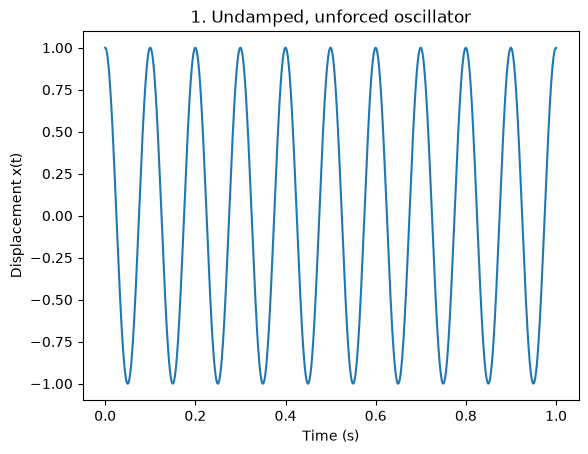

In [2]:
f0 = 10.0
w0 = 2*np.pi*f0
t = np.linspace(0, 1, 5000)

def simple_oscillator(t, y):
    x, v = y
    return [v, -w0**2*x]

s1 = solve_ivp(simple_oscillator, (t[0], t[-1]), [1, 0], t_eval=t)
plt.plot(s1.t, s1.y[0])
plt.xlabel("Time (s)"); plt.ylabel("Displacement x(t)")
plt.title("1. Undamped, unforced oscillator")
plt.show()

# 2. Add damping


Damping removes energy, so the motion fades.

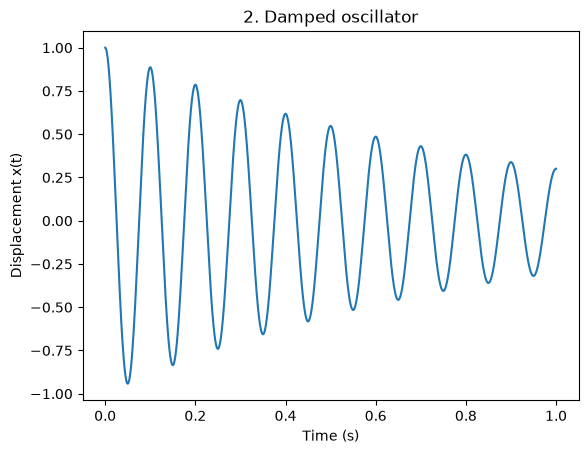

In [6]:
gamma = 1.2

def damped_oscillator(t, y):
    x, v = y
    return [v, -2*gamma*v - w0**2*x]

s2 = solve_ivp(damped_oscillator, (0, 1), [1, 0], t_eval=t)
plt.plot(s2.t, s2.y[0])
plt.xlabel("Time (s)"); plt.ylabel("Displacement x(t)")
plt.title("2. Damped oscillator")
plt.show()

## 3. Add an external drive

\\[
\\ddot{x}+2\\gamma\\dot{x}+\\omega_0^2x=F\\cos(\\omega_Dt)
\\]

The drive frequency \\(f_D\\) is close to resonance when it is near \\(f_0\\). Change `f_drive` to explore detuning.

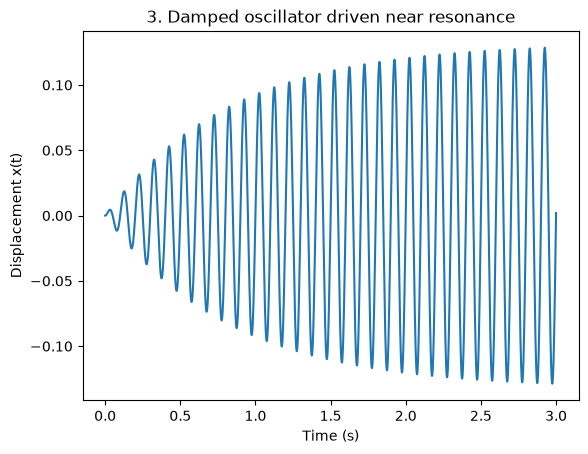

In [7]:
F = 20.0
f_drive = 10.0
w_drive = 2*np.pi*f_drive
t_drive = np.linspace(0, 3, 12000)

def driven_oscillator(t, y):
    x, v = y
    return [v, F*np.cos(w_drive*t) - 2*gamma*v - w0**2*x]

s3 = solve_ivp(driven_oscillator, (0, 3), [0, 0], t_eval=t_drive)
plt.plot(s3.t, s3.y[0])
plt.xlabel("Time (s)"); plt.ylabel("Displacement x(t)")
plt.title("3. Damped oscillator driven near resonance")
plt.show()